Basic imports:

In [36]:
import pandas as pd
import numpy as np
import sys
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

We read a small sample of 1,200 English words with phoneme transcriptions randomly sampled from the CELEX database (Baayen, Piepenbrock, & Gulikers, 1995):

In [2]:
sample = pd.read_csv("celex_en_sample.csv",sep=",").iloc[:,1:]
sample.head()

,Word,Frequency
0,& N g @ d,14
1,& N g r I @ r *,26
2,& b n O: m & l I t I z,15
3,& d,377
4,& d @ m b r e I t I d,1


We extract the phoneme frequencies:

In [3]:
phonfreqs = defaultdict(int)
for word in sample["Word"]:
    phons = word.split()
    for p in phons:
        phonfreqs[p] += 1
phonfreqs=pd.DataFrame(phonfreqs.items(),columns=["Phoneme","Frequency"])

In [4]:
phonfreqs.head()

,Phoneme,Frequency
0,&,164
1,N,105
2,g,108
3,@,624
4,d,550


# `sim_dirichlet` library

We import the Dirichlet functions:

In [5]:
sys.path.append('/Users/fermin/CODE/PYTHON3/') # just to add to my searchpath
from sym_dirichlet import *

We can now estimate $\alpha$ from symmetric Dirichlet prior using the method in Appendix~A

In [6]:
estimate_alpha_entropy(phonfreqs["Frequency"])

(np.float64(0.9740330128326953), np.float64(0.0011361354942903772))

So, the estimation is $\alpha=.974 \pm .001$. We can also plot the true vs predicted distribution. We can either use a fixed $\alpha$ value:

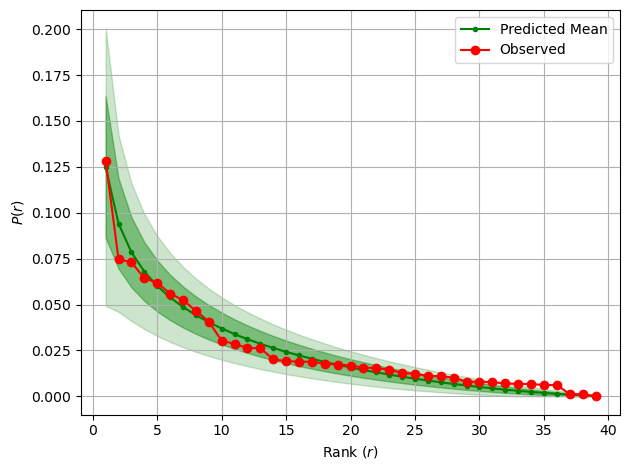

In [10]:
plot_ranks(phonfreqs["Frequency"],alpha=.7,types="Reversed",loglog=False)

Or have the function itself estimate $\alpha$ before plotting

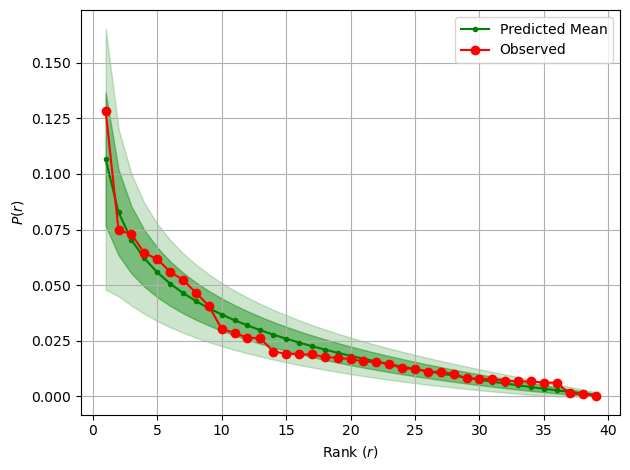

In [11]:
plot_ranks(phonfreqs["Frequency"],types="Reversed",loglog=False)

The library also has functions for computing the PDF and moments of the order statistics of a symmetric Dirichlet distribution.

# `phoneme_info` library

This library provides functions for computing the segment informativity ($I_s$) and the lexical information gain ($I_\ell$) given a list of words (optionally taking those words frequencies into consideration).

We first import the library

In [12]:
from phoneme_info import *

Now we compute $I_s$, not using just the types (using the default additive smoothing with $\alpha=.5$),

In [13]:
segment_info_type = segment_informativity(sample["Word"])
segment_info_type.head()

,Phoneme,Surprisal,Weight,Occurrences,Continuations
0,&,3.722927,164.0,164,164
1,*,5.285402,52.0,52,0
2,",",4.440306,143.0,143,79
3,3:,3.673302,57.0,57,57
4,@,3.656239,624.0,624,618


where the `Surprisal` column is $I_s$. We could also take the frequencies into consideration, and change the smoothing $\alpha$ to 1.0.

In [18]:
segment_info_token = segment_informativity(sample["Word"],sample["Frequency"],alpha=1)
segment_info_token.head()

,Phoneme,Surprisal,Weight,Occurrences,Continuations
0,&,1.173893,8674.0,164,164
1,*,5.285402,4020.0,52,0
2,",",5.247020,522119.0,143,79
3,3:,0.225157,6982.0,57,57
4,@,0.857130,36951.0,624,618


Similarly, we can compute $I_\ell$ based on types (using the default Chao-Wang-Jost entropy smoothing)

In [19]:
info_gain_type = phoneme_prefix_entropy(sample["Word"])
info_gain_type.head()

,Phoneme,Entropy,Weight,Prefixes
0,&,2.336570,164.0,74
1,*,0.046784,52.0,51
2,",",0.092406,143.0,138
3,3:,0.974308,57.0,41
4,@,1.686851,624.0,424


or taking the frequencies into account, and using plain maximum likelihood instead of smoothing

In [20]:
info_gain_token = phoneme_prefix_entropy(sample["Word"],sample["Frequency"],smoothing="ML")
info_gain_token.head()

,Phoneme,Entropy,Weight,Prefixes
0,&,0.764718,8674,74
1,*,0.004138,4020,51
2,",",0.000080,522119,138
3,3:,0.065430,6982,41
4,@,0.541000,36951,424


# `cost_fits` Library

Finally, we can use the $I_s$ and $I_\ell$ computed above to get the maximum entropy estimate of the phoneme distribution. First, we compute the mean values of each $I_s$ and $I_\ell$ using the type-based measures computed above, and we put them into an `array`

In [29]:
merged = pd.merge(phonfreqs, segment_info_type, on="Phoneme")
merged = pd.merge(merged, info_gain_type, on="Phoneme")

p = merged["Frequency"]/merged["Frequency"].sum()
Is = np.sum(p*merged["Surprisal"])
Il = np.sum(p*merged["Entropy"])
C = np.array((Is,Il))
C

array([3.84321817, 1.8582592 ])

We now create a matrix whose columns are the $I_s$ and $I_\ell$ values:

In [27]:
M = np.array(merged[["Surprisal","Entropy"]])

array([[3.72292714, 2.33656979],
       [4.81498414, 0.09267774],
       [3.65927975, 2.92011458],
       [3.65623853, 1.68685143],
       [4.39987087, 1.50791554],
       [3.5642095 , 2.89192015],
       [3.75455811, 1.10986113],
       [5.28540222, 0.04678444],
       [3.70164258, 3.35472792],
       [3.73484239, 1.58838988],
       [3.61113493, 1.59556414],
       [3.61831138, 2.4264685 ],
       [3.83411376, 1.25018972],
       [4.03462719, 1.4999007 ],
       [4.78156145, 0.209995  ],
       [3.45037579, 0.58399387],
       [3.52802802, 2.76963758],
       [4.03913132, 3.19474343],
       [3.59102295, 1.48001352],
       [3.6603984 , 3.35695547],
       [3.78081391, 3.87942811],
       [3.63868969, 0.83736836],
       [3.59663301, 1.04349808],
       [4.03054254, 1.32782801],
       [3.76749003, 3.65115436],
       [4.44030634, 0.09240563],
       [3.86648583, 1.47083605],
       [3.84730583, 0.53648855],
       [3.67330201, 0.97430806],
       [3.7725895 , 0.        ],
       [3.

We can now load the library and compute the the maximum entropy:

In [31]:
from cost_fits import *
probs,lambdas = compute_maxent_from_matrix(M,C)

The guessed $\lambda$ values are:

In [32]:
lambdas

array([0.05988202, 0.07510081])

And the guessed probabilities relate to the actual probabilities

Text(0, 0.5, '(log) guessed probability')

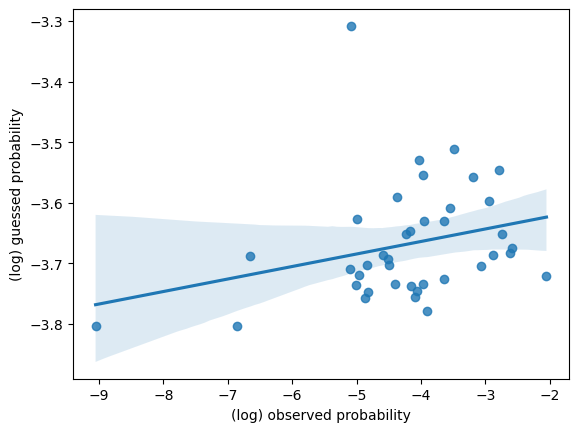

In [40]:
sns.regplot(x=np.log(p),y=np.log(probs))
plt.xlabel("(log) observed probability")
plt.ylabel("(log) guessed probability")